# Import Necessary Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage
import warnings
warnings.filterwarnings("ignore")

# EDA

In [2]:
df=pd.read_csv("/kaggle/input/mall-customers-segmentation/Mall_Customers.csv")
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Check Nulls

In [4]:
df.isna().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Check Duplicated

In [5]:
df.duplicated().sum()

0

# Analysis

In [6]:
gen=df["Genre"].value_counts()
gen

Genre
Female    112
Male       88
Name: count, dtype: int64

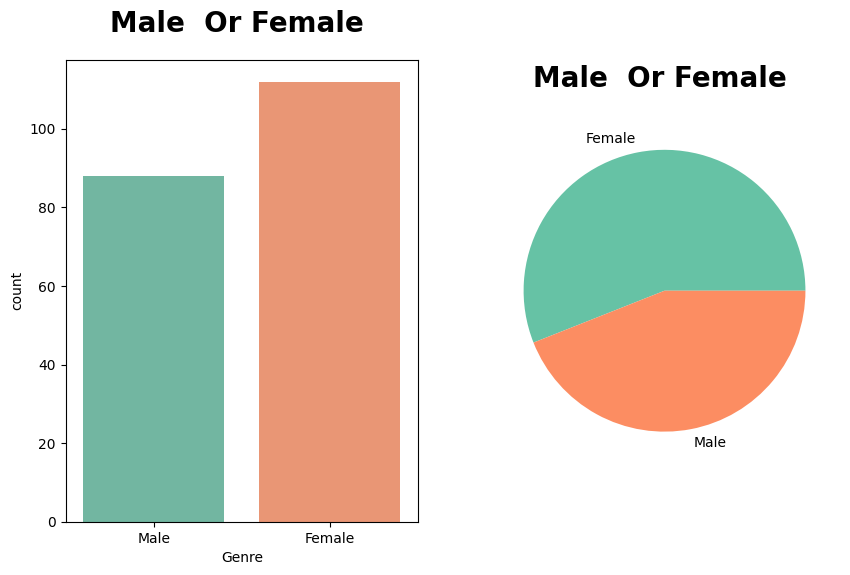

In [7]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.countplot(data=df,x="Genre",color=sns.set_palette("Set2"))
plt.title("Male  Or Female ",pad=20,fontweight="black",size=20)
plt.subplot(1,2,2)
plt.pie(gen.values,labels=gen.index,colors=sns.set_palette("Set2"))
plt.title("Male  Or Female ",pad=20,fontweight="black",size=20)
plt.show()


In [8]:
df["Age"].describe()

count    200.000000
mean      38.850000
std       13.969007
min       18.000000
25%       28.750000
50%       36.000000
75%       49.000000
max       70.000000
Name: Age, dtype: float64

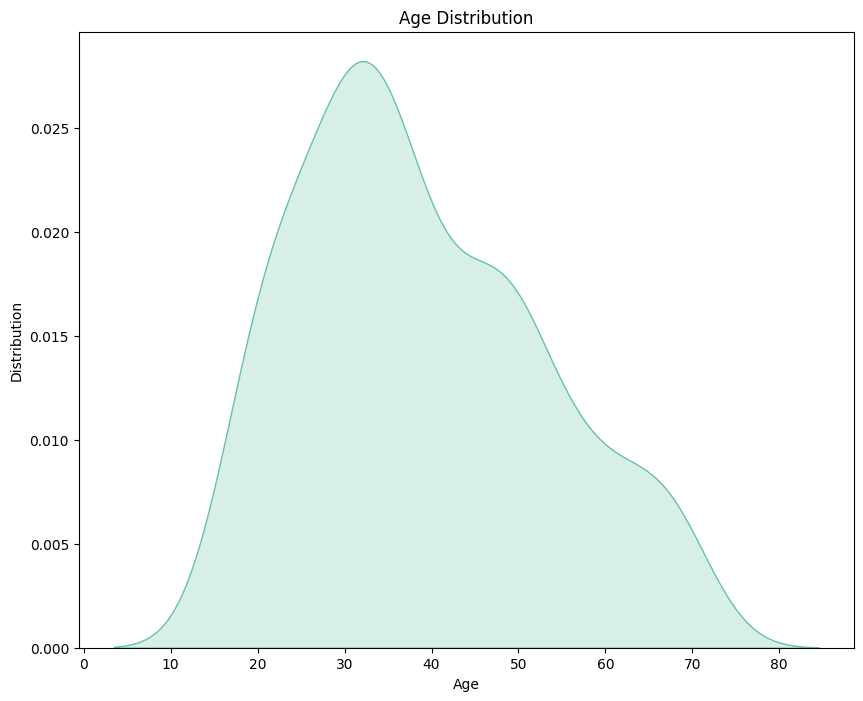

In [9]:
plt.figure(figsize=(10,8))
sns.kdeplot(df["Age"],fill=True,palette="Set2")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Distribution")
plt.show()

In [10]:
df["Annual Income (k$)"].describe()

count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income (k$), dtype: float64

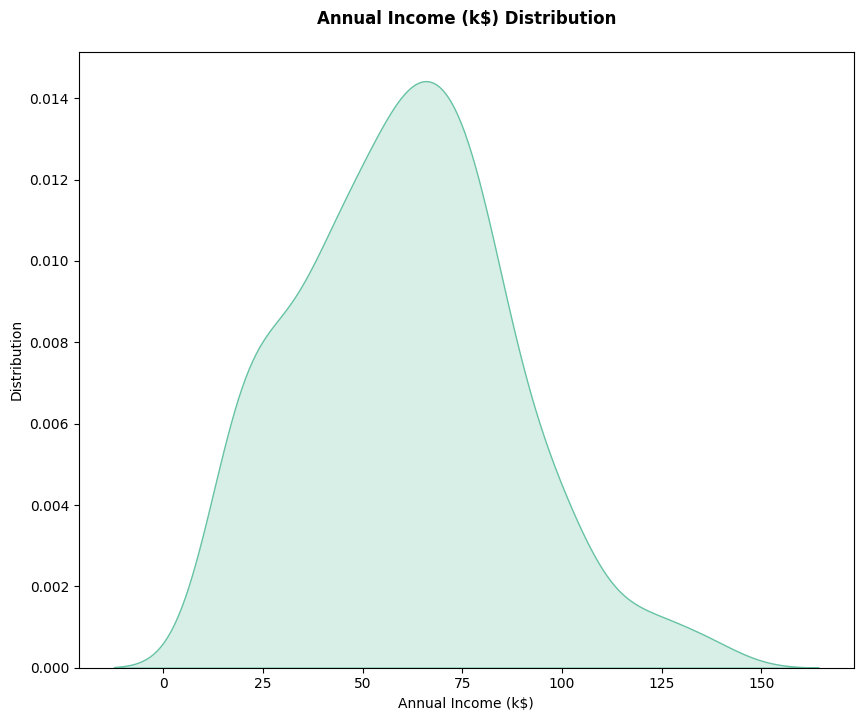

In [11]:
plt.figure(figsize=(10,8))
sns.kdeplot(df["Annual Income (k$)"],fill=True,palette="Set2")
plt.title("Annual Income (k$) Distribution",pad=20,fontweight="black")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Distribution")
plt.show()

In [12]:
df["Spending Score (1-100)"].describe()

count    200.000000
mean      50.200000
std       25.823522
min        1.000000
25%       34.750000
50%       50.000000
75%       73.000000
max       99.000000
Name: Spending Score (1-100), dtype: float64

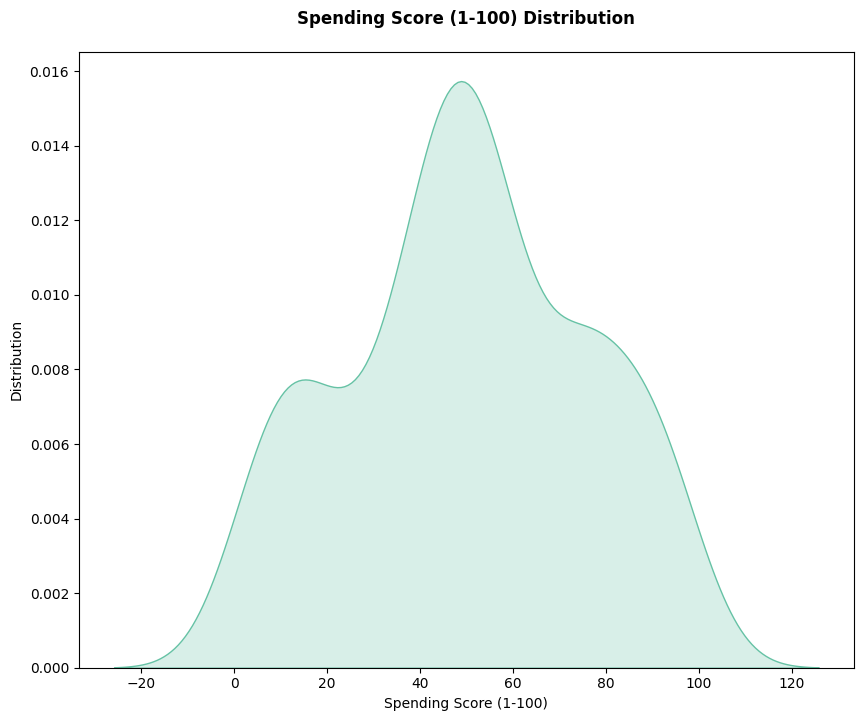

In [13]:
plt.figure(figsize=(10,8))
sns.kdeplot(df["Spending Score (1-100)"],fill=True,palette="Set2")
plt.title("Spending Score (1-100) Distribution",pad=20,fontweight="black")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Distribution")
plt.show()

# Preprocessing 

# Drop Uneeded Columns

In [14]:
df.drop(columns="CustomerID",inplace=True,axis=1)


# Encodeing

In [15]:
encoder=LabelEncoder()

In [16]:
df["Genre"]=encoder.fit_transform(df["Genre"])


# Scaling

In [17]:
scaler=StandardScaler()

In [18]:
#df=scaler.fit_transform(df)

# Elbow Method

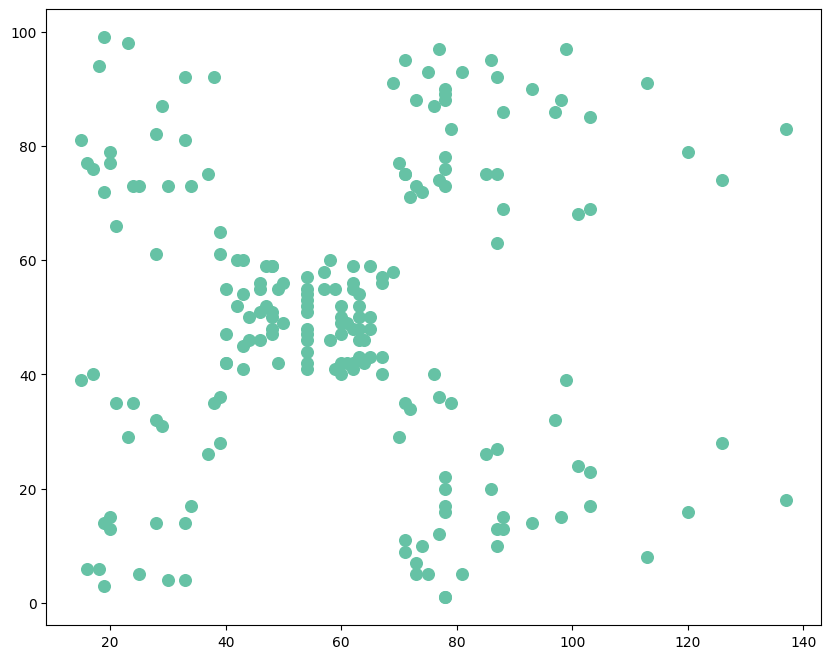

In [19]:
plt.figure(figsize=(10,8))
plt.scatter(df["Annual Income (k$)"],df["Spending Score (1-100)"],s=70)
plt.show()

In [20]:
inretia = []
for i in range(1,11):
    kmean=KMeans(n_clusters=i)
    kmean.fit(df)
    inretia.append(kmean.inertia_)

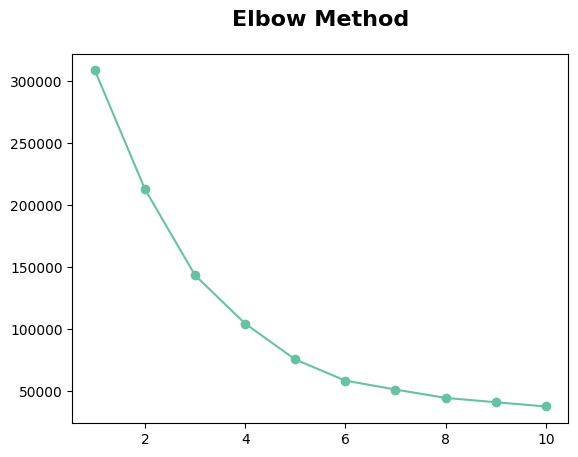

In [21]:
plt.title("Elbow Method",fontweight="black",pad=20,size=16)
plt.plot(np.arange(1,11),inretia,marker="o")

plt.show()


In [22]:
kmean=KMeans(n_clusters=5)
df["Cluster"]=kmean.fit_predict(df)

In [23]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,0
1,1,21,15,81,4
2,0,20,16,6,0
3,0,23,16,77,4
4,0,31,17,40,0
...,...,...,...,...,...
195,0,35,120,79,2
196,0,45,126,28,3
197,1,32,126,74,2
198,1,32,137,18,3


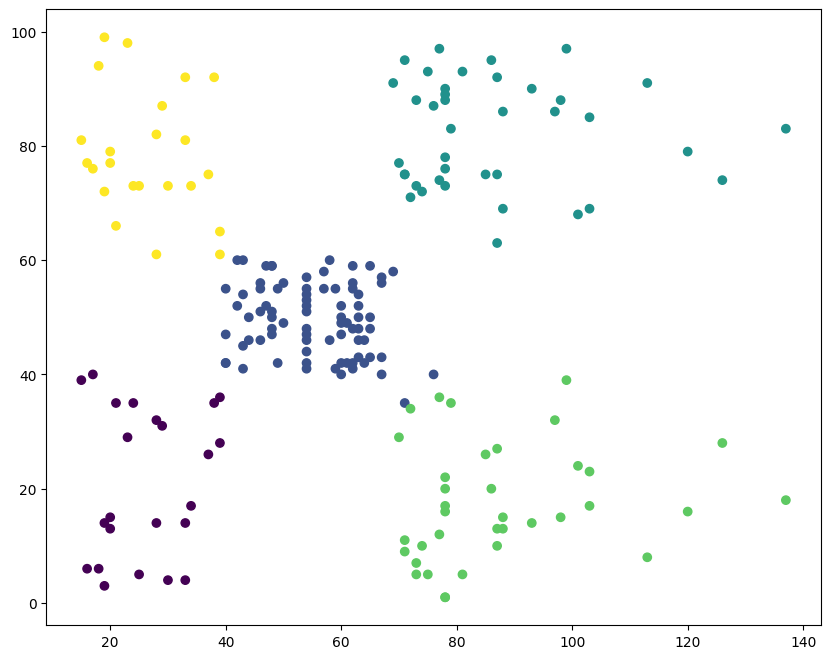

In [24]:
plt.figure(figsize=(10,8))
plt.scatter(df["Annual Income (k$)"],df["Spending Score (1-100)"],c=df["Cluster"])
plt.show()

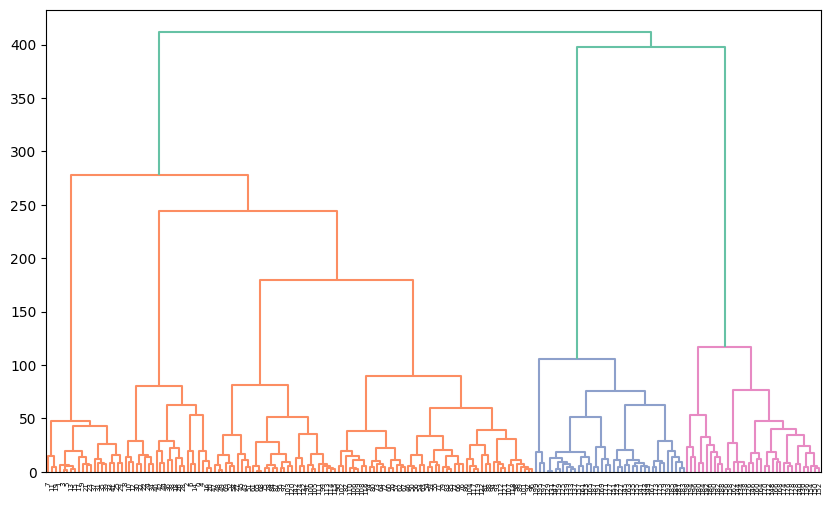

In [25]:
z=linkage(df,method="ward")
plt.figure(figsize=(10,6))
dendrogram(z,p=5)
plt.show()

In [26]:
agg_clus=AgglomerativeClustering(n_clusters=3,linkage="ward")
df["Ag_cluster"]=agg_clus.fit_predict(df[["Genre","Age"	,"Annual Income (k$)","Spending Score (1-100)"]])

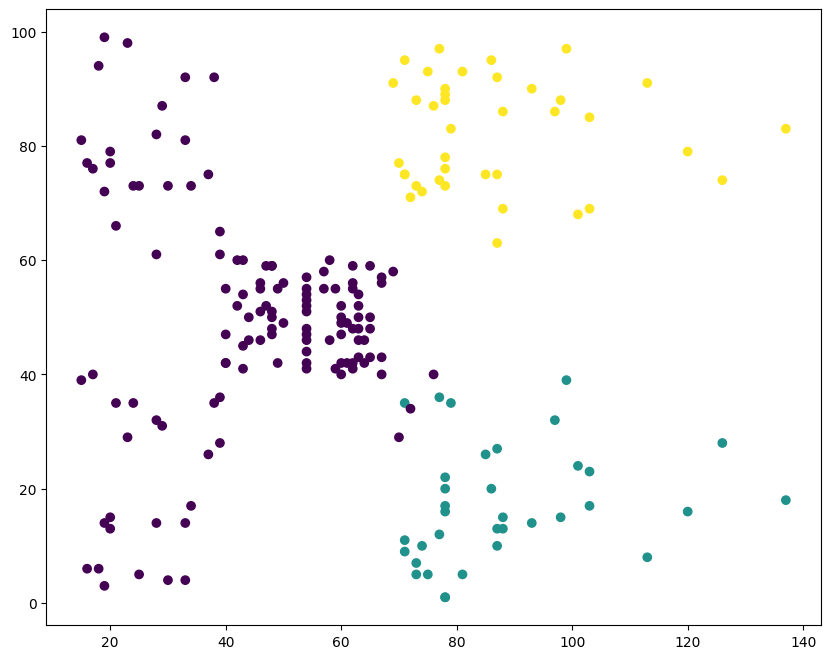

In [27]:
plt.figure(figsize=(10,8))
plt.scatter(df["Annual Income (k$)"],df["Spending Score (1-100)"],c=df["Ag_cluster"])
plt.show()

In [28]:
dbscan=DBSCAN(eps=14,min_samples=5)
df["DBSCA"]=dbscan.fit_predict(df[["Genre","Age","Annual Income (k$)","Spending Score (1-100)"]])

In [29]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Ag_cluster,DBSCA
0,1,19,15,39,0,0,-1
1,1,21,15,81,4,0,0
2,0,20,16,6,0,0,-1
3,0,23,16,77,4,0,0
4,0,31,17,40,0,0,0
...,...,...,...,...,...,...,...
195,0,35,120,79,2,2,-1
196,0,45,126,28,3,1,-1
197,1,32,126,74,2,2,-1
198,1,32,137,18,3,1,-1


# -1 mean is Outlier 

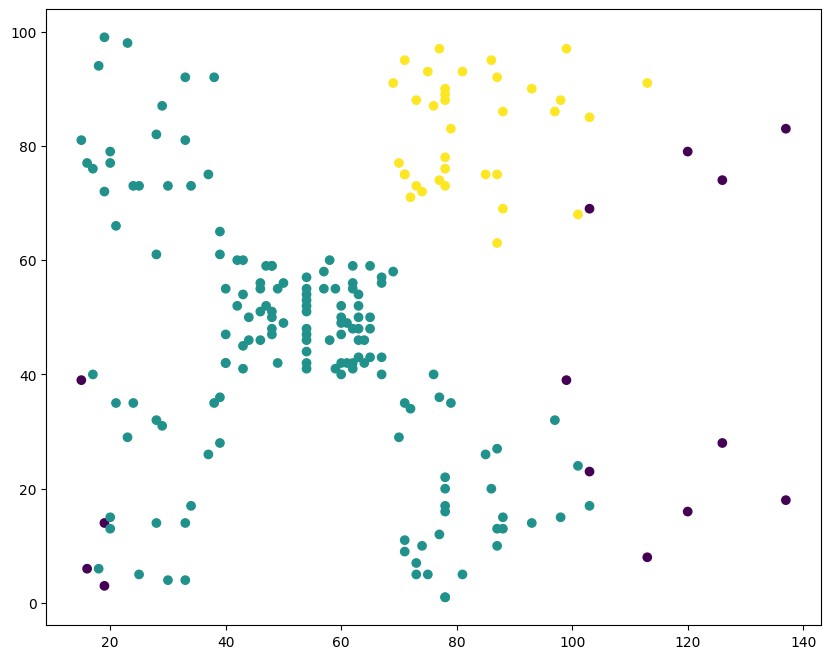

In [30]:
plt.figure(figsize=(10,8))
plt.scatter(df["Annual Income (k$)"],df["Spending Score (1-100)"],c=df["DBSCA"])
plt.show()

# Consider best on is Kmean

In [31]:
df.drop(columns=["Ag_cluster","DBSCA"],inplace=True)

In [32]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,0
1,1,21,15,81,4
2,0,20,16,6,0
3,0,23,16,77,4
4,0,31,17,40,0
...,...,...,...,...,...
195,0,35,120,79,2
196,0,45,126,28,3
197,1,32,126,74,2
198,1,32,137,18,3


In [33]:
df.to_csv("output.csv",index=False)